<a href="https://colab.research.google.com/github/Mayank191297/Deep-Learning-Projects/blob/main/cnn_mask_mayank_raghuwanshi_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from zipfile import ZipFile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive")

['MyDrive',
 '.shortcut-targets-by-id',
 '.file-revisions-by-id',
 '.Trash-0',
 '.Encrypted']

In [ ]:
dataset = '/content/archive (26) - Copy.zip'

In [ ]:
import zipfile
import os
from zipfile import ZipFile
zip_path = '/content/drive/MyDrive/LNCT/archive (27) - Copy.zip' # Change this to your uploaded file's path
extract_path = "/content/my_folder1"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['data']

In [ ]:
!ls

drive  my_folder1  sample_data


Importing necessary **libraries**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split


In [ ]:
os.listdir()

['.config', 'drive', 'my_folder1', 'sample_data']

In [ ]:
mask_data = os.listdir('/content/my_folder1/data/with_mask')
without_mask_data = os.listdir('/content/my_folder1/data/without_mask')

In [ ]:
mask_data[0:5]

['with_mask_3688.jpg',
 'with_mask_2170.jpg',
 'with_mask_258.jpg',
 'with_mask_1957.jpg',
 'with_mask_1837.jpg']

In [ ]:
mask_data[:-5:-1]

['with_mask_417.jpg',
 'with_mask_2778.jpg',
 'with_mask_680.jpg',
 'with_mask_799.jpg']

In [ ]:
without_mask_data[:5:1]

['without_mask_3388.jpg',
 'without_mask_2048.jpg',
 'without_mask_451.jpg',
 'without_mask_3547.jpg',
 'without_mask_381.jpg']

In [ ]:
without_mask_data[:-5:-1]

['without_mask_1828.jpg',
 'without_mask_3690.jpg',
 'without_mask_3495.jpg',
 'without_mask_3743.jpg']

In [ ]:
print("Total images with mask",len(mask_data))

Total images with mask 3725


In [ ]:
print("Total images without mask",len(without_mask_data))

Total images without mask 3828


Creating labels For mask and without

In [ ]:
mask_data_op = [1]*3725
without_mask_data_op = [0]*3828

In [ ]:
print(mask_data_op[:5:1])
print(without_mask_data_op[:5:1])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
Target = mask_data_op + without_mask_data_op
len(Target)

7553

displaying the images using matplotlib

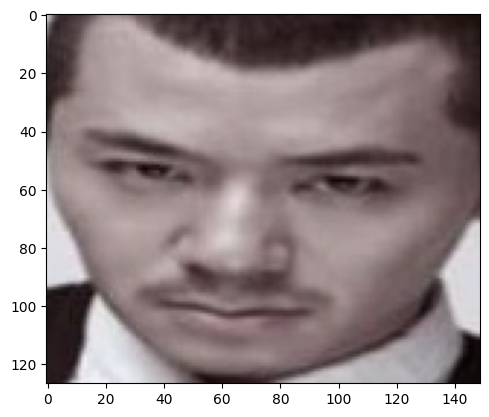

In [ ]:
img = mpimg.imread('/content/my_folder1/data/without_mask/without_mask_100.jpg')
imgplot = plt.imshow(img)
plt.show()

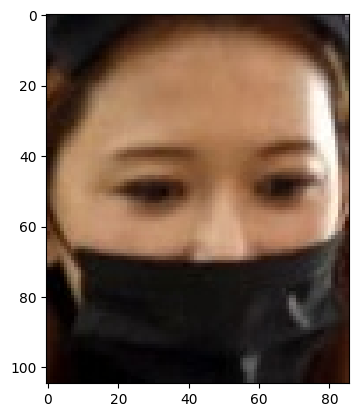

In [ ]:
img = mpimg.imread('/content/my_folder1/data/with_mask/with_mask_100.jpg')
imgplot = plt.imshow(img)
plt.show()

Preprocessing tha image data by resizing and converting them into an araray

In [ ]:
#Converting mask images to np array
mask_path='/content/my_folder1/data/with_mask/'
data = []

In [ ]:
for img_file in mask_data:
  image = Image.open(mask_path + img_file)
  image = image.resize((128,128))
  image=image.convert('RGB')
  data.append(np.array(image))
print(len(data))

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


3725


array([[[216, 164,  62],
        [215, 163,  61],
        [214, 162,  61],
        ...,
        [238, 238, 211],
        [218, 214, 181],
        [220, 211, 170]],

       [[219, 169,  67],
        [218, 168,  67],
        [219, 167,  67],
        ...,
        [239, 239, 211],
        [215, 210, 177],
        [213, 204, 163]],

       [[217, 169,  68],
        [218, 168,  68],
        [218, 167,  68],
        ...,
        [235, 232, 204],
        [217, 211, 178],
        [217, 207, 166]],

       ...,

       [[207, 159,  85],
        [206, 159,  81],
        [198, 151,  68],
        ...,
        [165, 140, 109],
        [160, 135, 104],
        [160, 135, 104]],

       [[207, 159,  85],
        [206, 158,  81],
        [198, 152,  68],
        ...,
        [166, 141, 110],
        [158, 133, 102],
        [159, 134, 103]],

       [[206, 158,  84],
        [205, 157,  80],
        [197, 150,  67],
        ...,
        [167, 142, 111],
        [156, 131, 100],
        [158, 133, 102]]], dtype=uint8)
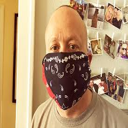

In [ ]:
data[0]

In [ ]:
#Converting without mask images to np array
without_mask_path='/content/my_folder1/data/without_mask/'

for img_file in without_mask_data:
  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image=image.convert('RGB')
  data.append(np.array(image))
print(len(data))

7553


In [ ]:
print(len(data))
print(data[0].shape)

7553
(128, 128, 3)


In [ ]:
X = np.array(data)
y = np.array(Target)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(y)

numpy.ndarray

In [ ]:
X.shape

(7553, 128, 128, 3)

In [ ]:
y.shape

(7553,)

In [ ]:
print(y)

[1 1 1 ... 0 0 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((6042, 128, 128, 3), (1511, 128, 128, 3), (6042,), (1511,))

Scaling the dataset

In [ ]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255


building a model CNN

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers  import Dense

In [ ]:
model = Sequential()

In [ ]:
model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation = 'relu',input_shape=(128,128,3)))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

In [ ]:
model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation = 'relu'))

In [ ]:
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

In [ ]:
model.add(keras.layers.Flatten())

In [ ]:
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1,activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
X_train_scaled.shape,y_train.shape

((6042, 128, 128, 3), (6042,))

In [ ]:
history = model.fit(X_train_scaled, y_train)

189/189 ━━━━━━━━━━━━━━━━━━━━ 165s 864ms/step - accuracy: 0.6635 - loss: 0.6990


In [ ]:
loss,accuracy = model.evaluate(X_test_scaled,y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - accuracy: 0.8778 - loss: 0.2940


In [ ]:
#Predictive system

Path of the image to be predicted: /content/yogi ji.png


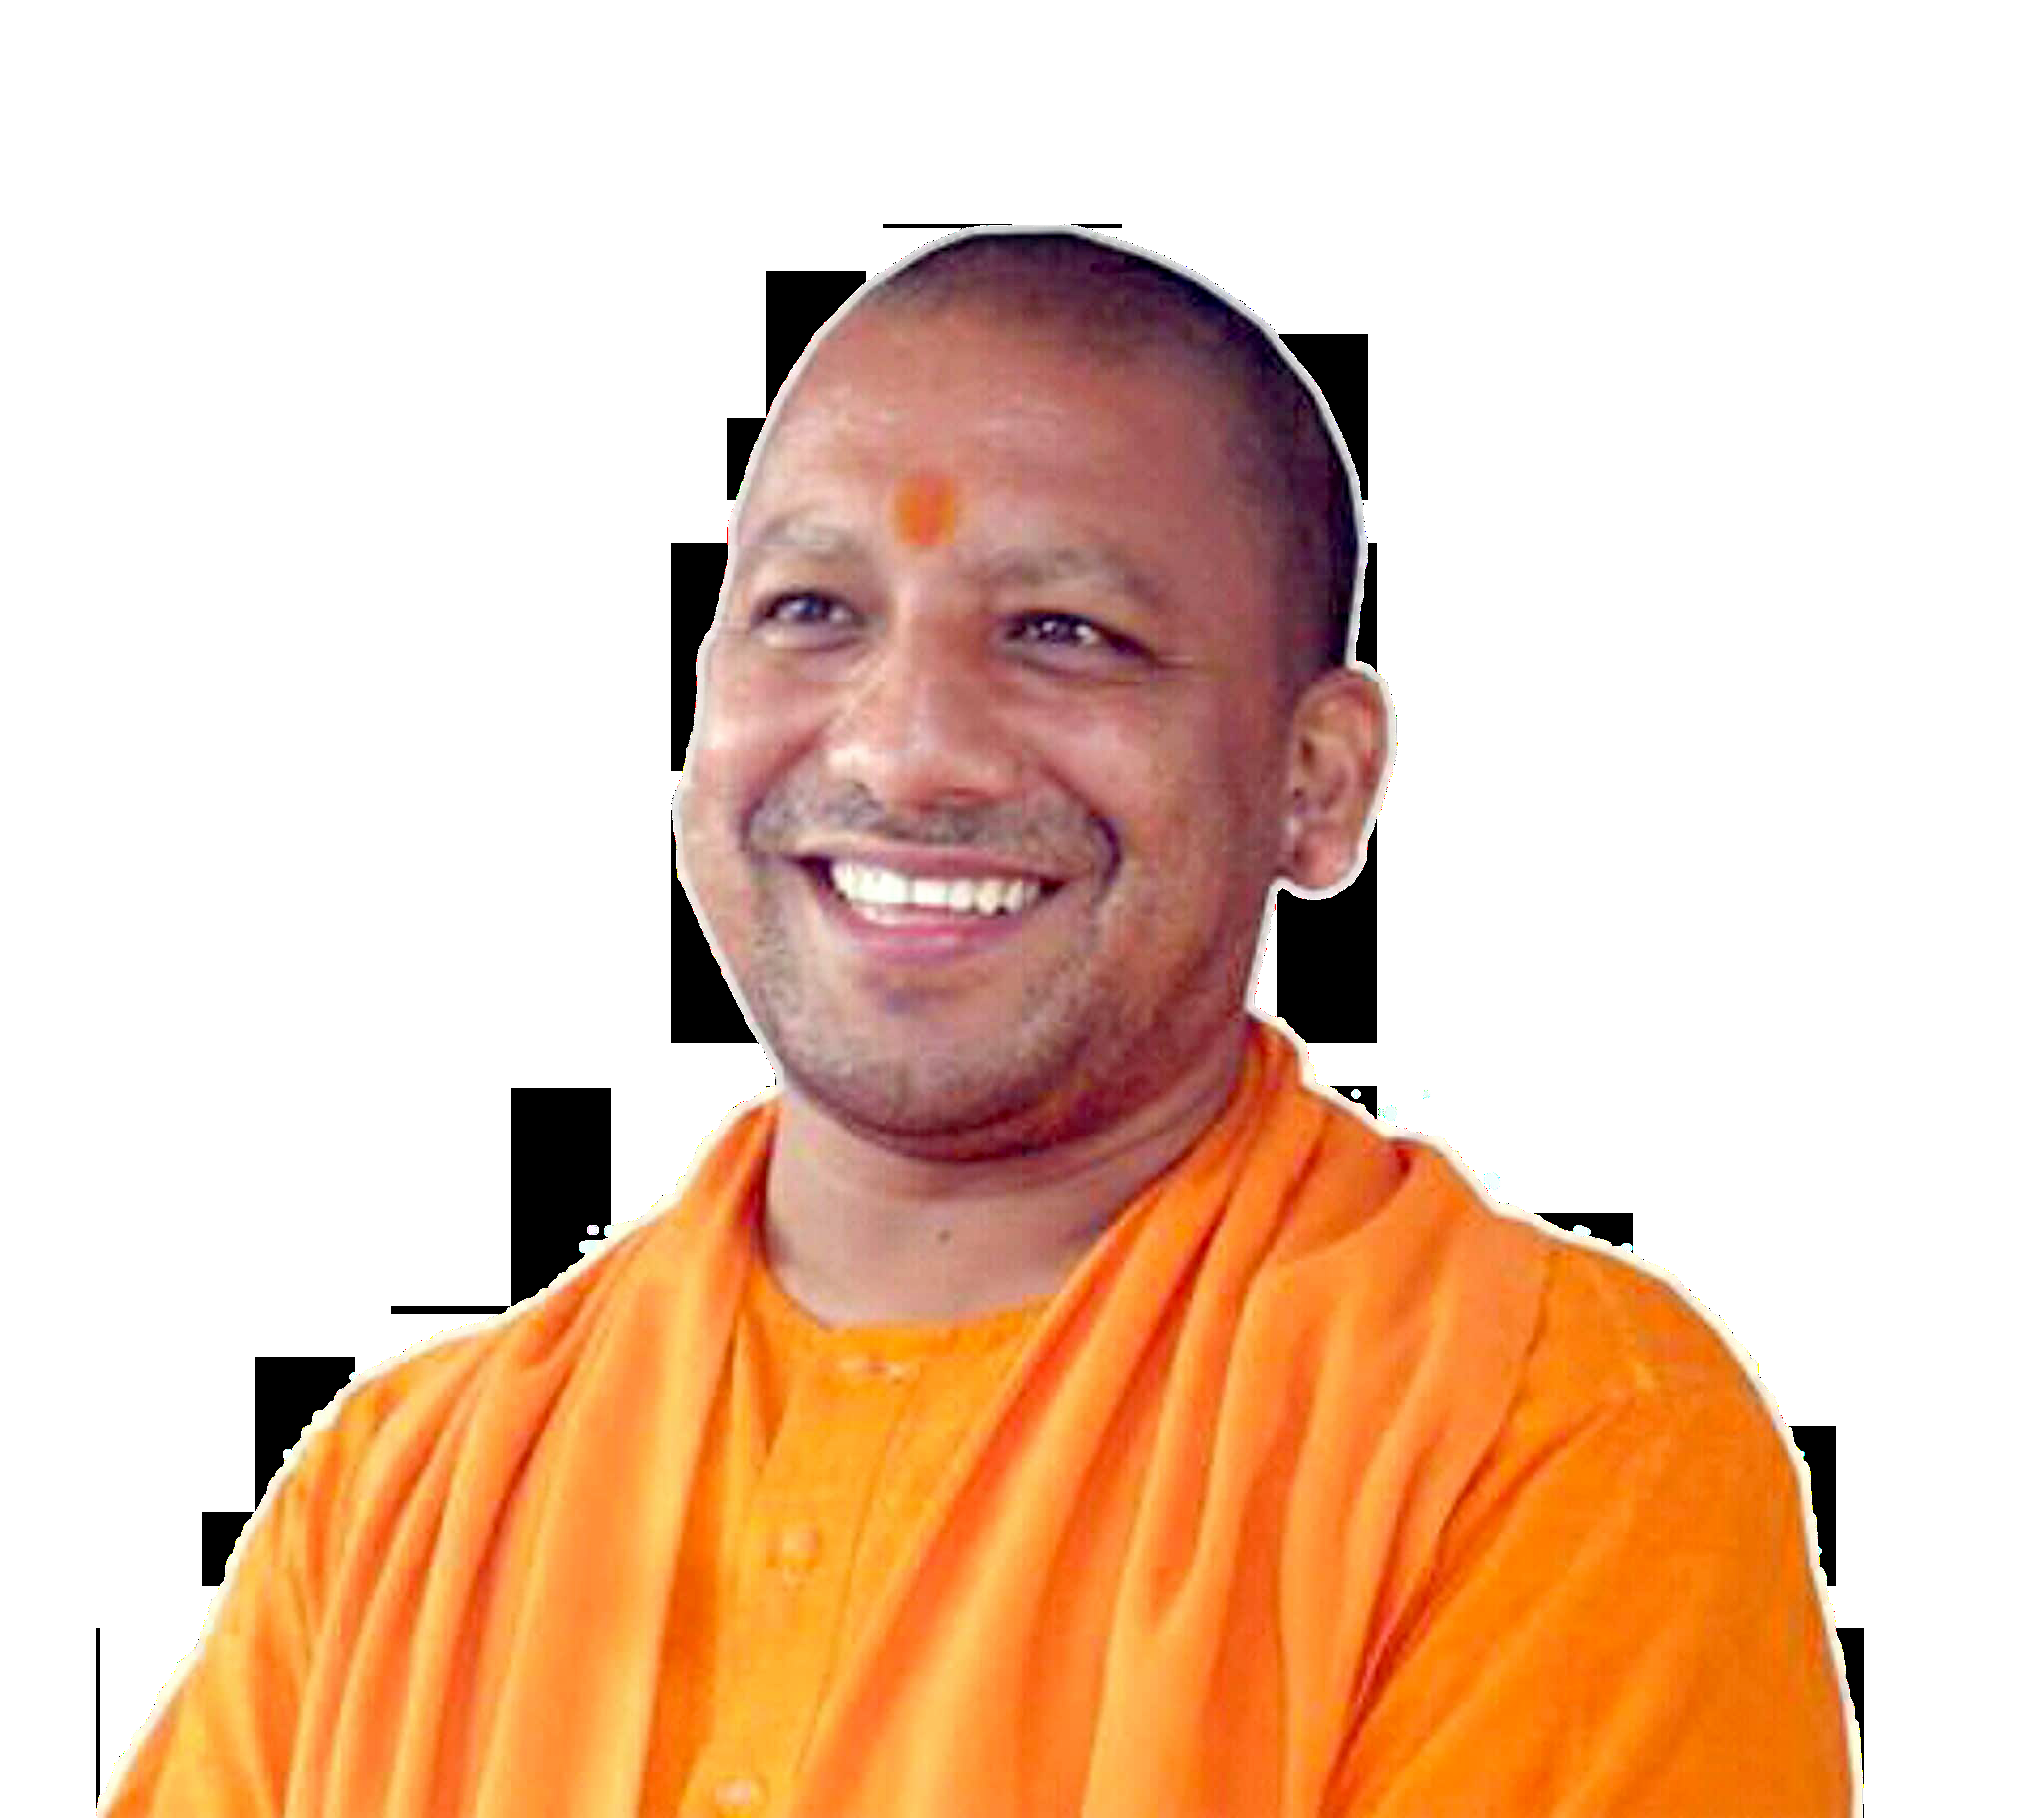

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
[[0.9991314]]
0
The person in the image is not wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

In [ ]:
#Saving the model

In [ ]:
model.save("cnn_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("cnn_model.h5")  # Load the model


Enter the image path: /content/yogi ji.png


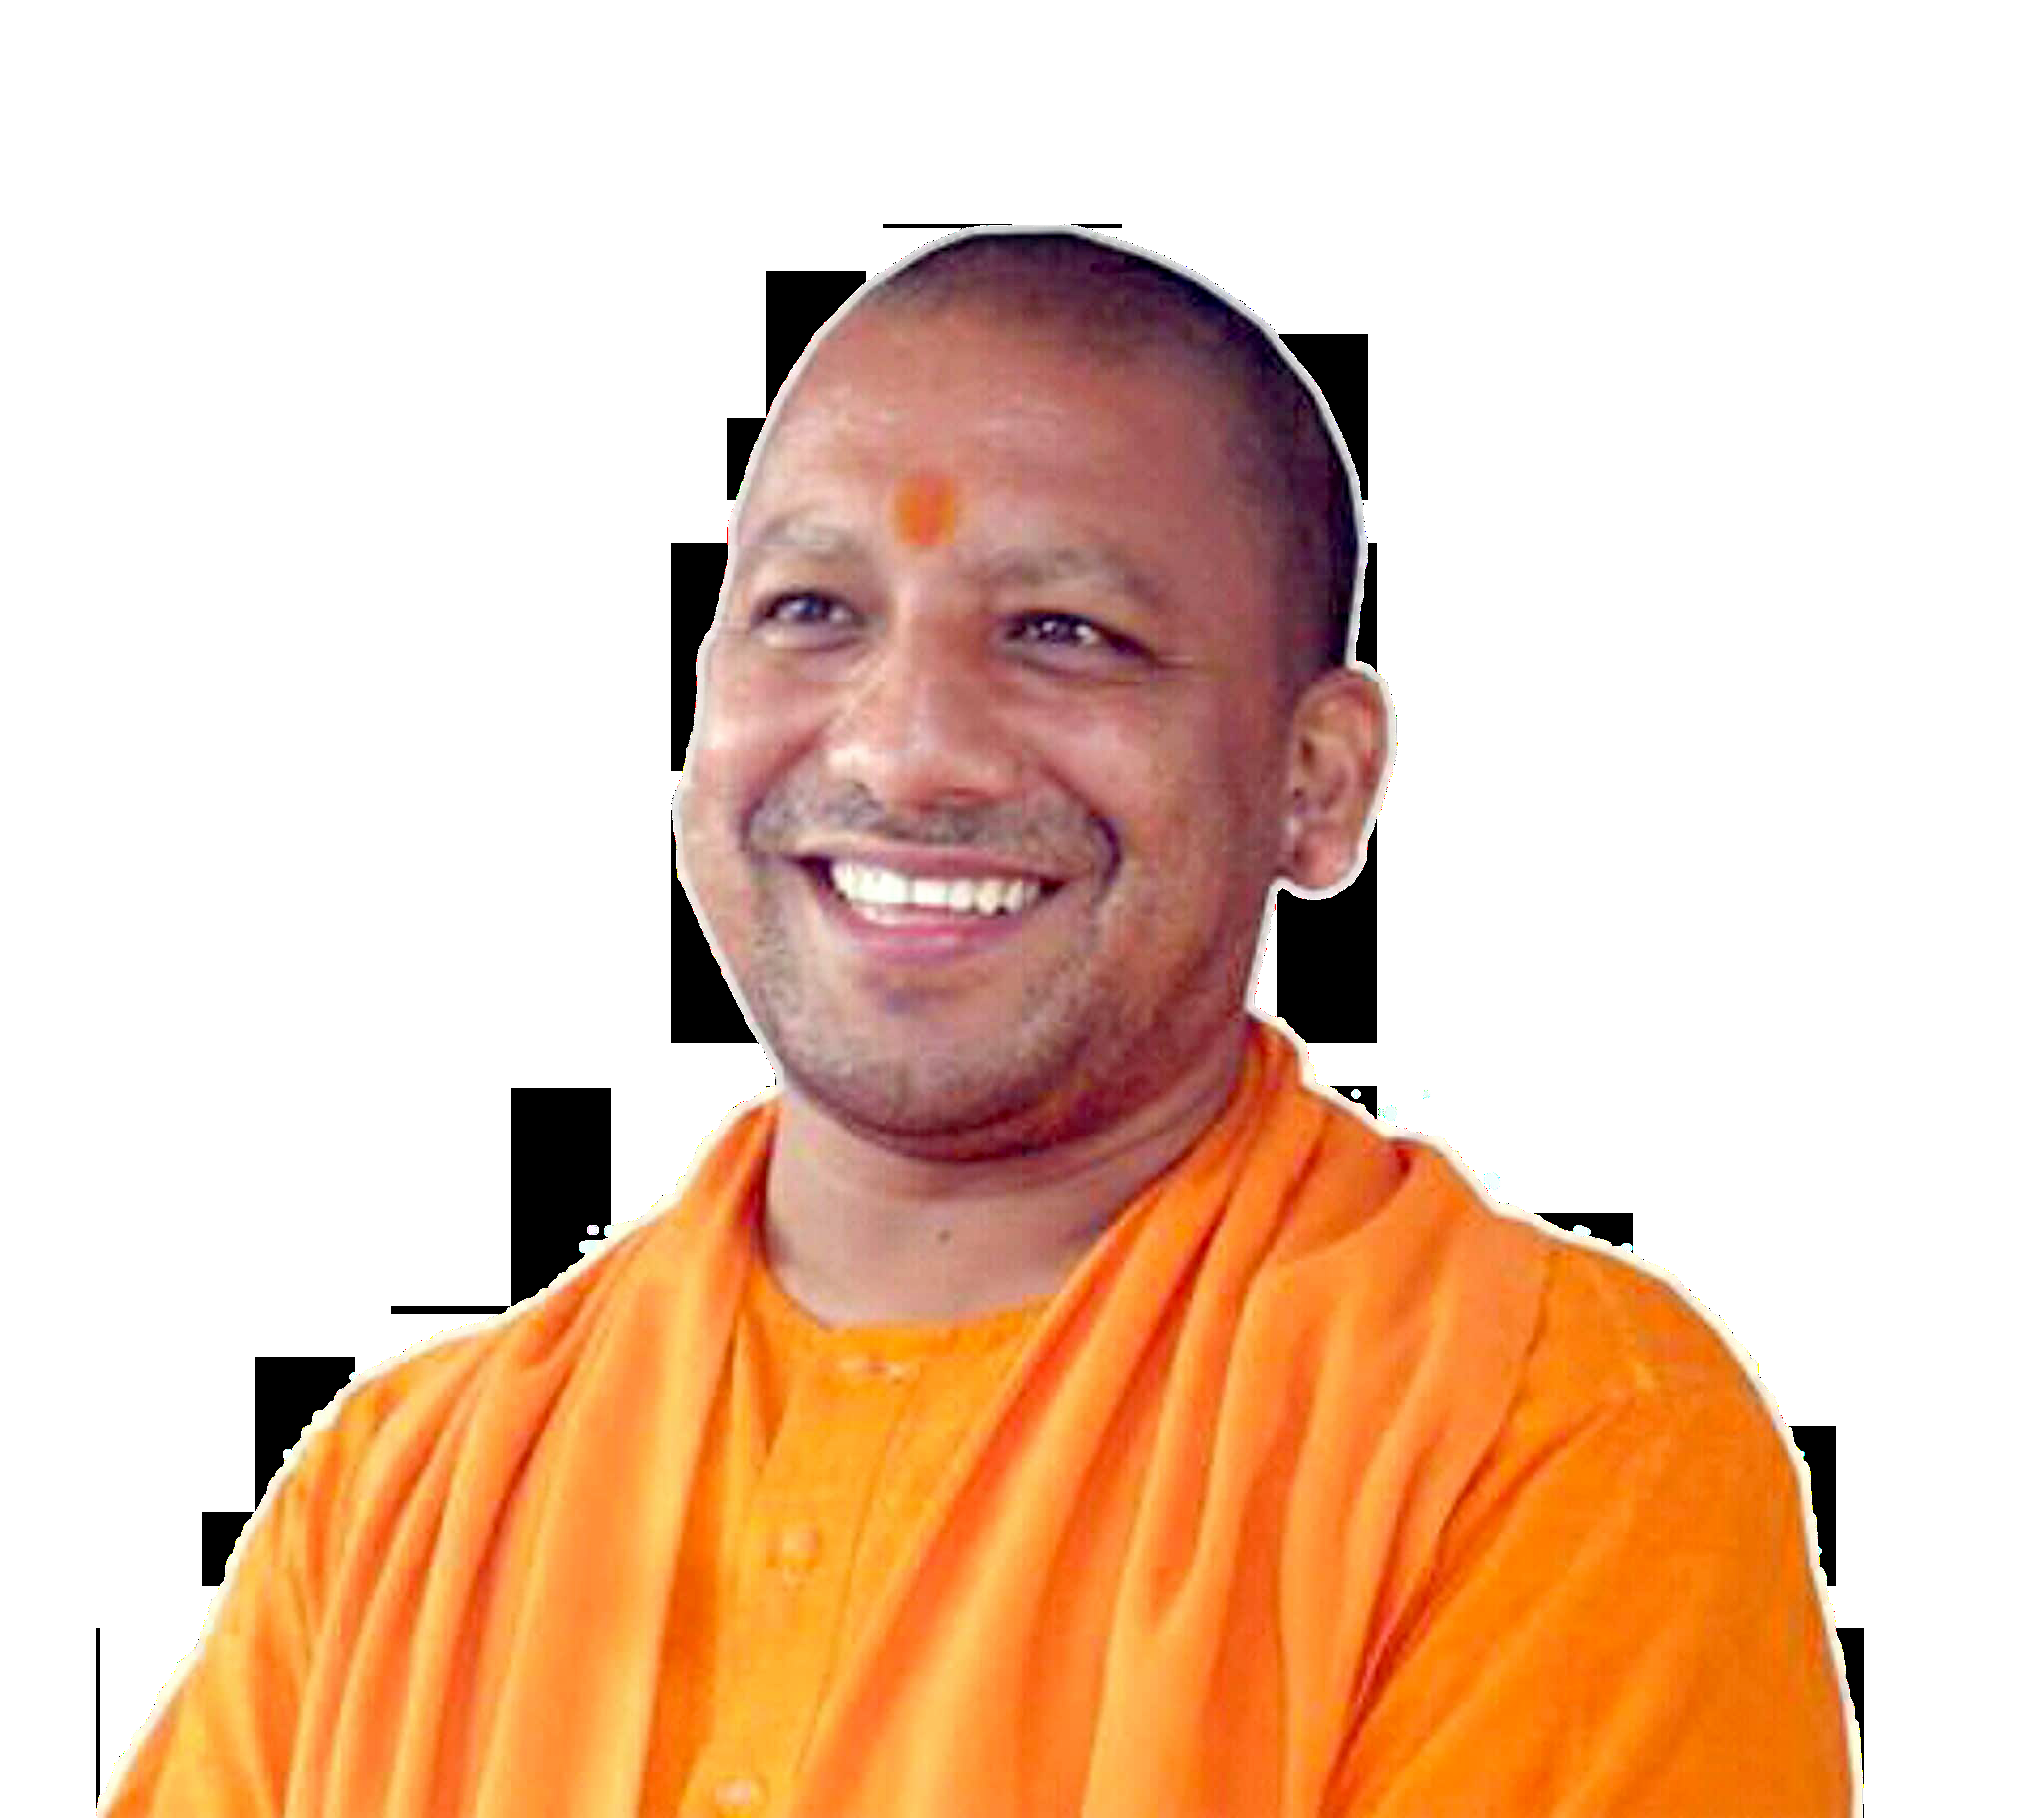

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Raw Prediction Output: [[0.9991314]]
The person in the image is NOT wearing a mask ❌


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow

model = load_model("cnn_model.h5")

def predict_mask(image_path):
    """
    Predicts whether a person in the given image is wearing a mask or not.

    Args:
        image_path (str): Path to the image file.

    Returns:
        None (Prints the prediction result)
    """
    input_image = cv2.imread(image_path)


    if input_image is None:
        print("Error: Unable to load image. Check the path and try again.")
        return


    cv2_imshow(input_image)


    input_image_resized = cv2.resize(input_image, (128, 128))

    input_image_scaled = input_image_resized / 255.0

    # Reshape to match model input
    input_image_reshaped = np.expand_dims(input_image_scaled, axis=0)

    input_prediction = model.predict(input_image_reshaped)
    print("Raw Prediction Output:", input_prediction)

    input_pred_label = np.argmax(input_prediction)
    if input_pred_label == 1:
        print("The person in the image is wearing a mask 😷")
    else:
        print("The person in the image is NOT wearing a mask ❌")

# Example Usage
image_path = input("Enter the image path: ")
predict_mask(image_path)
